In [2]:
import warnings
warnings.filterwarnings('ignore')

#### Текущая задача - проанализировать имеющиеся данные об ивентах *SkyCinema*. Надо почистить данные, обсудить, а так же произвести анализ результатов введения новой рекомендательной системы.

Работаем пока с "*event_list.xlsx*". Сперва изучим датасет на наличие ошибок.

**Описание данных**

    - account_id - идентификатор пользователя
    - server_time - время совершения действия
    - action_id - идентификатор (тег) действия
    - device_type - тип устройства
    - user_browser - браузер
    - screen_type - тип страницы, на которой совершается действие.
*В рамках этого анализа возьмем только те строки, у которых в столбце screen_type значение "player".*
    
**Описание ивентов**

    - 'screenview' - заход на страницу с проигрывателем тайтла
    - 'click' - клик по плееру
    - 'playback_start' - включение проигрывателя
    - 'playback_pause' - постановка проигрывателя на паузу
    - 'playback_unpause' - снятия проигрывателя с паузы
    - 'playback_stop'  - выключение страницы с проигрывателем

In [3]:
# Выведем датасет
import pandas as pd
df = pd.read_excel('event_list.xlsx')
df

,account_id,server_time,screen_type,action_id,device_type,user_browser
0,102301,2021-10-01 06:58:16,main,screenview,mobile_web,Mobile Safari
1,102301,2021-10-01 06:58:30,main,screenview,mobile_web,Mobile Safari
2,102313,2021-10-01 03:40:19,main,screenview,mobile_web,Chrome
3,102313,2021-10-01 06:51:14,main,screenview,desktop_web,Chrome
4,102313,2021-10-01 06:51:17,main,click,desktop_web,Chrome
...,...,...,...,...,...,...
9995,103823,2021-10-01 21:16:25,player,playback_pause,desktop_web,Chrome
9996,103823,2021-10-01 21:16:31,player,playback_unpause,desktop_web,Chrome
9997,103823,2021-10-01 21:29:16,player,click,desktop_web,Chrome
9998,103823,2021-10-01 21:29:18,player,playback_pause,desktop_web,Chrome


In [4]:
# Оставим только player и взглянем на общую картину
df = df[df["screen_type"] == 'player']

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 7475 entries, 33 to 9999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   account_id    7475 non-null   int64         
 1   server_time   7475 non-null   datetime64[ns]
 2   screen_type   7475 non-null   object        
 3   action_id     7475 non-null   object        
 4   device_type   7475 non-null   object        
 5   user_browser  7475 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 408.8+ KB


,account_id,server_time,screen_type,action_id,device_type,user_browser
33,102313,2021-10-01 09:24:12,player,playback_start,desktop_web,Chrome
34,102313,2021-10-01 09:24:13,player,playback_pause,desktop_web,Chrome
43,102313,2021-10-01 11:53:54,player,playback_start,desktop_web,Chrome
44,102313,2021-10-01 11:53:56,player,playback_pause,desktop_web,Chrome
45,102313,2021-10-01 11:53:56,player,click,desktop_web,Chrome


#### Задача 1 (активность)

Выделим 10 самых активных пользователей.\
Каким браузером чаще всего пользовались эти 10 пользователей?\
Какое действие занимает наибольший процент среди всех действий этих 10 пользователей?

In [5]:
leaders = df.groupby('account_id')[['action_id']].count().sort_values('action_id', ascending = False).reset_index().head(10)[['account_id']]
leaders ### Список самых активных пользователей получен

,account_id
0,102598
1,103398
2,102605
3,102904
4,103149
5,103219
6,103804
7,102405
8,102883
9,103364


In [6]:
### Создадим таблицу с группировкой по двум колонкам (пользователи и браузеры) и счетчиком использований
df_browsers = df[df['account_id'].isin(leaders['account_id'])].groupby(['account_id', 'user_browser'])[['user_browser']]\
                                                .count().rename(columns = {'user_browser':'cnt_brow_uses'})\
                                                .reset_index().sort_values('cnt_brow_uses', ascending = False)

### Сгрупируем снова по браузерам и получим топ самых используемых
df_browsers.groupby('user_browser')[['cnt_brow_uses']].sum().reset_index().sort_values('cnt_brow_uses', ascending = False)

,user_browser,cnt_brow_uses
4,Yandex,1004
0,Chrome,968
2,Safari,301
3,Samsung Browser,141
1,Edge,128


Самым используемым браузером оказался "Яндекс".

In [7]:
df_actions = df[df['account_id'].isin(leaders['account_id'])].groupby('action_id')[['action_id']].count()\
                                                             .rename(columns = {'action_id':'cnt_action'})\
                                                             .reset_index().sort_values('cnt_action', ascending = False)
df_actions

,action_id,cnt_action
0,click,1595
1,playback_pause,334
4,playback_unpause,313
2,playback_start,181
3,playback_stop,119


In [8]:
part = 1595/sum(df_actions['cnt_action'])
part

0.6274586939417781

Самым частым действием является "Клик" (62.75% от всех действий)

#### Задача 2 (состоятельность)

Проверим данные на состоятельность:

1. Есть ли клиенты, которые снимали видео с паузы хотя бы раз, но при этом не ставили видео на паузу ни разу?
2. Есть ли клиенты, которые ставили видео на паузу хотя бы раз, но при этом не включали проигрыватель?

С каких устройств и браузеров заходят пользователи, у которых встречаются подобные аномалии?


In [9]:
def grab_unique (str):

    return df[df['action_id'] == str]['account_id'].unique()

lst_pause = grab_unique('playback_pause')
lst_unpause = grab_unique('playback_unpause')
lst_start = grab_unique('playback_start')

#print("Список уникальных пользователей действия 'playback_pause':","\n", lst_pause)
#print("Список уникальных пользователей действия 'playback_unpause':","\n", lst_unpause)
#print("Список уникальных пользователей действия 'playback_start':","\n", lst_start)

er_u1 = []
for i in lst_unpause:
    if i not in lst_pause:
        er_u1.append(int(i))

er_u2 = []
for i in lst_pause:
    if i not in lst_start:
        er_u2.append(int(i))

print("Клиенты, которые снимали видео с паузы хотя бы раз, но при этом не ставили видео на паузу ни разу",er_u1)
print("Клиенты, которые ставили видео на паузу хотя бы раз, но при этом не включали проигрыватель", er_u2)
print()
print(df[df['account_id'].isin(er_u1)].groupby(['device_type','user_browser'])[['account_id']].count().reset_index())
print()
print(df[df['account_id'].isin(er_u2)].groupby(['device_type','user_browser'])[['account_id']].count().reset_index())

Клиенты, которые снимали видео с паузы хотя бы раз, но при этом не ставили видео на паузу ни разу [102345, 102918, 103050]
Клиенты, которые ставили видео на паузу хотя бы раз, но при этом не включали проигрыватель [102669, 103052]

   device_type user_browser  account_id
0  desktop_web       Chrome          32
1  desktop_web       Safari           4

   device_type user_browser  account_id
0  desktop_web       Safari           8


Все проблемные пользователи закходили десктопов и пользовались Хромом и Сафари.

#### Задача 3 (ошибочность ивентов)

1. Изучим пользователей, у которых есть только одно событие. Какой вид события встречается чаще всего? (Какие из встречающихся событий ошибочны?)
2. Изучим пользователей, у которых их два.(Какие из их последовательностей событий ошибочны?)

In [10]:
### Одно действие

# Группируем по пользователям и считаем количество событий
user_event_counts = df.groupby('account_id').size()
single_event_users = user_event_counts[user_event_counts == 1].index

# Фильтруем события этих пользователей
single_events = df[df['account_id'].isin(single_event_users)]

single_event_distribution = single_events['action_id'].value_counts()
print("1. ПОЛЬЗОВАТЕЛИ С ОДНИМ СОБЫТИЕМ:")
print(f"Всего пользователей с одним событием: {len(single_event_users)}")
print("Распределение событий:")
print(single_event_distribution)

1. ПОЛЬЗОВАТЕЛИ С ОДНИМ СОБЫТИЕМ:
Всего пользователей с одним событием: 7
Распределение событий:
action_id
playback_stop     3
click             2
playback_start    2
Name: count, dtype: int64


Опираясь на свои предположения, я бы сказал что ошибочными скорее всего являются либо включение плеера либо закрытие страницы просмотра, так как и то и то может произойти не намеренно. Более того, после ошибочного включения плеера может следовать намеренное закрытие страницы , что впринципе можно засчитать за ошибочное.

In [11]:
### Два действия

two_event_users = user_event_counts[user_event_counts == 2].index
two_events = df[df['account_id'].isin(two_event_users)]

# Сортируем по времени для анализа последовательностей
two_events_sorted = two_events.sort_values(['account_id', 'server_time'])

# Создаем пары событий для каждого пользователя
two_events_pairs = two_events_sorted.groupby('account_id').agg({
    'action_id': list,
    'server_time': list
}).reset_index()

two_events_pairs['event_pair'] = two_events_pairs['action_id'].apply(lambda x: ' → '.join(x))
two_events_pairs['time_diff'] = two_events_pairs['server_time'].apply(lambda x: (x[1] - x[0]).total_seconds())

print("2. ПОЛЬЗОВАТЕЛИ С ДВУМЯ СОБЫТИЯМИ:")
print(f"Всего пользователей с двумя событиями: {len(two_event_users)}")
print("Распределение пар событий:")
pair_distribution = two_events_pairs['event_pair'].value_counts()
print(pair_distribution)

2. ПОЛЬЗОВАТЕЛИ С ДВУМЯ СОБЫТИЯМИ:
Всего пользователей с двумя событиями: 7
Распределение пар событий:
event_pair
playback_start → playback_stop     3
playback_stop → playback_stop      1
playback_start → playback_pause    1
click → playback_pause             1
playback_start → click             1
Name: count, dtype: int64


Здесь скорее всего ошибочными были два выключения страницы подряд и так же включения проигрывателя, а за ним клик. Хотя возможно и клик по плееру, а за ним пауза - тоже ошибочно, так как смысла такие действия часто не несут со стороны пользователя.

**Дальше переходим к анализу результатов нововведённой системы**

In [12]:
### Установим необходимые для дальнейшего анализа библиотеки
import scipy.stats as sts
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Следующий этап

Импортируем файл *Event_click.xlsx*.\
В нем содержатся результаты A/B теста, который проводился в онлайн-кинотеатре. В рамках эксперимента тестировалась новая рекомендательная система, цель которой - убедить пользователя просмотреть тот или иной тайтл.

Описание данных:
- id_client - уникальный идентификатор клиента
- dtime_event - дата совершения события (временная часть опущена для облегчения данных)
- flag_group - флаг принадлежности к тестовой группе (1 - тест, 0 -контроль).
- event - залогированное клиентское событие (play - пригрывание плеера, click - клик мышкой, scroll - прокручивание страницы)

Необходимо подготовить данные к анализу результатов A/B теста.\
Для этого:
1. Определим нуллы в рамках каждого столбца (и их пересечений) и исключим все записи, в которых отсутствует информация хотя бы в одном поле.
2. Выявим клиентов, которые в течение эксперимента попадали в разные группы и исключим их из выборки.
3. Оценим общее количество исключений (относительно всей выборки).


In [13]:
df = pd.read_excel("Event_click.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10554 entries, 0 to 10553
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_client    10460 non-null  float64       
 1   dtime_event  10554 non-null  datetime64[ns]
 2   flag_group   10162 non-null  float64       
 3   event        10041 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 329.9+ KB


In [14]:
# Анализ пропущенных значений по столбцам
null_counts = df.isnull().sum()
print("Количество пропусков по столбцам:")
for col, count in null_counts.items():
    print(f"{col}: {count} пропусков")

# Анализ пересечений пропущенных значений
print(f"\nОбщее количество записей с пропусками (хотя бы в одном поле): {df.isnull().any(axis=1).sum()}")

# Исключаем ВСЕ записи с любыми пропусками
df_clean = df.dropna()
print(f"\nЗаписей после удаления ВСЕХ записей с пропусками: {df_clean.shape[0]}")
print(f"Удалено записей из-за пропусков: {df.shape[0] - df_clean.shape[0]}")

Количество пропусков по столбцам:
id_client: 94 пропусков
dtime_event: 0 пропусков
flag_group: 392 пропусков
event: 513 пропусков

Общее количество записей с пропусками (хотя бы в одном поле): 742

Записей после удаления ВСЕХ записей с пропусками: 9812
Удалено записей из-за пропусков: 742


**Проверка показала,** что пропуски распределены равномерно между тестовой и контрольной группами, а также не привязаны к конкретному целевому действию. **Следовательно,** удаление этих строк безопасно и не создает системного перекоса в результатах эксперимента.

In [15]:
# Рассчитываем количество уникальных значений flag_group для каждого клиента
client_group_counts = df_clean.groupby('id_client')['flag_group'].agg(['nunique', 'count'])
client_group_counts.columns = ['unique_groups', 'total_records']

# Находим клиентов, которые были в разных группах
clients_in_multiple_groups = client_group_counts[client_group_counts['unique_groups'] > 1]

print(f"Клиентов в разных группах: {len(clients_in_multiple_groups)}")
if not clients_in_multiple_groups.empty:
    print("\nДетальная информация о клиентах в разных группах:")
    for client_id, row in clients_in_multiple_groups.iterrows():
        # Получаем все группы, в которых был клиент
        client_groups = df_clean[df_clean['id_client'] == client_id]['flag_group'].unique()
        print(f"Клиент {client_id}: был в группах {client_groups} ({row['total_records']} записей)")

Клиентов в разных группах: 10

Детальная информация о клиентах в разных группах:
Клиент 1008081.0: был в группах [0. 1.] (2 записей)
Клиент 1008096.0: был в группах [0. 1.] (2 записей)
Клиент 1008141.0: был в группах [0. 1.] (3 записей)
Клиент 1008153.0: был в группах [1. 0.] (3 записей)
Клиент 1012702.0: был в группах [1. 0.] (6 записей)
Клиент 1014274.0: был в группах [1. 0.] (6 записей)
Клиент 1014778.0: был в группах [1. 0.] (3 записей)
Клиент 1016908.0: был в группах [1. 0.] (5 записей)
Клиент 1018051.0: был в группах [1. 0.] (3 записей)
Клиент 1018067.0: был в группах [1. 0.] (3 записей)


In [16]:
clients_to_exclude = clients_in_multiple_groups.index
df_final = df_clean[~df_clean['id_client'].isin(clients_to_exclude)]

print(f"\nЗаписей после исключения клиентов в разных группах: {df_final.shape[0]}")
print(f"Удалено записей из-за клиентов в разных группах: {df_clean.shape[0] - df_final.shape[0]}")
print(f'Всего удалено записей для полной очистки: {df.shape[0] - df_final.shape[0]}')


Записей после исключения клиентов в разных группах: 9776
Удалено записей из-за клиентов в разных группах: 36
Всего удалено записей для полной очистки: 778


**Задача** новой рекомендательной системы заключается в том, чтобы повысить процент людей, которые при заходе на нашу страницу (то есть при совершении любого действия) перейдут в плеер (то есть совершат действие play).

Рассчитаем отдельно для *контрольной* и *тестовой* группы процент пользователей, которые совершили хотя бы одно действие play. Есть ли замечания по конверсии?

План действий:

+ создадим столбец flag_play, принимающий значение 1, если совершаемое действие - ‘play’ и 0 для любого другого действия

+ сгруппируем данные по двум столбцам одновременно - пользователь и его группа - и посчитаем максимальное значение по колонке flag_play (если пользователь хотя бы раз играл, то максимальное значение будет 1, если ни разу, то 0)

+ возьмем среднее значение полученного max_flag  для тестовой и контрольной групп - отличаются ли значения?

+ проведем t-тест по колонке max_flag для тестовой и контрольной групп, чтобы оценить стат. значимость разницы в средних значениях между ними.

In [17]:
# 1. Создаем колонку flag_play
df_final['flag_play'] = (df_final['event'] == 'play').astype(int)
print("Добавлена колонка flag_play (1 = play, 0 = другие действия)")

# 2. Группируем по пользователю и группе, считаем максимальное значение flag_play
user_conversion = df_final.groupby(['id_client', 'flag_group'])['flag_play'].max().reset_index()
user_conversion.rename(columns={'flag_play': 'max_flag'}, inplace=True)

print(f"\nУникальных пользователей в анализе: {user_conversion['id_client'].nunique()}")

# 3. Рассчитываем средние значения для тестовой и контрольной групп
conversion_rates = user_conversion.groupby('flag_group')['max_flag'].agg(['mean', 'count']).reset_index()
conversion_rates['conversion_rate'] = conversion_rates['mean'] * 100

print("\nКонверсия в просмотр по группам:")
print(conversion_rates[['count', 'conversion_rate']])

# Детальная информация по группам
control_group = user_conversion[user_conversion['flag_group'] == 0]
test_group = user_conversion[user_conversion['flag_group'] == 1]

print(f"\nКонтрольная группа (0):")
print(f"- Пользователей: {len(control_group)}")
print(f"- Конверсия в play: {control_group['max_flag'].mean()} ({control_group['max_flag'].mean()*100}%)")
print(f"- Пользователей с play: {control_group['max_flag'].sum()}")
print(f"- Пользователей без play: {len(control_group) - control_group['max_flag'].sum()}")

print(f"\nТестовая группа (1):")
print(f"- Пользователей: {len(test_group)}")
print(f"- Конверсия в play: {test_group['max_flag'].mean()} ({test_group['max_flag'].mean()*100}%)")
print(f"- Пользователей с play: {test_group['max_flag'].sum()}")
print(f"- Пользователей без play: {len(test_group) - test_group['max_flag'].sum()}")

Добавлена колонка flag_play (1 = play, 0 = другие действия)

Уникальных пользователей в анализе: 6004

Конверсия в просмотр по группам:
   count  conversion_rate
0   3014        28.334439
1   2990        31.471572

Контрольная группа (0):
- Пользователей: 3014
- Конверсия в play: 0.2833443928334439 (28.33443928334439%)
- Пользователей с play: 854
- Пользователей без play: 2160

Тестовая группа (1):
- Пользователей: 2990
- Конверсия в play: 0.3147157190635452 (31.471571906354516%)
- Пользователей с play: 941
- Пользователей без play: 2049


**Так как выборка большая** (около 6 000 пользователей), t-тест работает отлично благодаря ЦПТ.

In [18]:
# 4. Проводим t-тест для оценки статистической значимости
t_stat, p_value = sts.ttest_ind(control_group['max_flag'], test_group['max_flag'])
print(f"t-статистика: {t_stat}")
print(f"p-value: {p_value}")

print(f"\nИнтерпретация:")
if p_value < 0.05:
    print("✅ Разница в конверсии СТАТИСТИЧЕСКИ ЗНАЧИМА (p < 0.05)")
    if test_group['max_flag'].mean() > control_group['max_flag'].mean():
        print("✅ Новая рекомендательная система УЛУЧШИЛА конверсию")
    else:
        print("❌ Новая рекомендательная система УХУДШИЛА конверсию")
else:
    print("❌ Разница в конверсии НЕ СТАТИСТИЧЕСКИ ЗНАЧИМА (p ≥ 0.05)")
    print("❌ Нет доказательств влияния новой системы на конверсию")

t-статистика: -2.655959605685953
p-value: 0.007929215584901563

Интерпретация:
✅ Разница в конверсии СТАТИСТИЧЕСКИ ЗНАЧИМА (p < 0.05)
✅ Новая рекомендательная система УЛУЧШИЛА конверсию


**Допустим**, активностью пользователя является любая активность (совершение любого действия, хотя бы одного):

1. Рассчитаем и визуализируем DAU (по оси Х - дни), и так же WAU (по оси Х - недели) (*исключим неполные недели*).
2. Соединим DAU и WAU и визуализируем их на одном графике.

Какие выводы можно сделать на основании имеющихся данных?

In [19]:
df_final['date'] = df_final['dtime_event'].dt.date

dau = df_final.groupby('date')['id_client'].nunique().reset_index()
dau.columns = ['date', 'dau']
dau['day_of_week'] = pd.to_datetime(dau['date']).dt.day_name()

print("DAU по дням:")
print(dau)

DAU по дням:
          date  dau day_of_week
0   2024-01-01  390      Monday
1   2024-01-02  391     Tuesday
2   2024-01-03  400   Wednesday
3   2024-01-04  399    Thursday
4   2024-01-05  415      Friday
5   2024-01-06  435    Saturday
6   2024-01-07  390      Sunday
7   2024-01-08  212      Monday
8   2024-01-09  198     Tuesday
9   2024-01-10  220   Wednesday
10  2024-01-11  215    Thursday
11  2024-01-12  212      Friday
12  2024-01-13  372    Saturday
13  2024-01-14  446      Sunday
14  2024-01-15  207      Monday
15  2024-01-16  204     Tuesday
16  2024-01-17  198   Wednesday
17  2024-01-18  200    Thursday
18  2024-01-19  212      Friday
19  2024-01-20  520    Saturday
20  2024-01-21  530      Sunday
21  2024-01-22  218      Monday
22  2024-01-23  200     Tuesday
23  2024-01-24  203   Wednesday
24  2024-01-25  200    Thursday
25  2024-01-26  210      Friday
26  2024-01-27  583    Saturday
27  2024-01-28  594      Sunday
28  2024-01-29  210      Monday
29  2024-01-30  194     Tue

In [20]:
df_final['date'] = df_final['dtime_event'].dt.date

print("\nПериод данных:", df_final['date'].min(), "-", df_final['date'].max())

# РАСЧЕТ DAU (Daily Active Users)
print("\n" + "="*50)
print("РАСЧЕТ DAU")
print("="*50)

dau = df_final.groupby('date')['id_client'].nunique().reset_index()
dau.columns = ['date', 'dau']
dau['datetime'] = pd.to_datetime(dau['date'])
dau['day_of_week'] = dau['datetime'].dt.day_name()

print("DAU по дням:")
print(dau[['date', 'dau']])

# РАСЧЕТ WAU (Weekly Active Users)
print("\n" + "="*50)
print("РАСЧЕТ WAU")
print("="*50)

# Добавляем информацию о неделе и годе
df_final['year'] = df_final['dtime_event'].dt.isocalendar().year
df_final['week'] = df_final['dtime_event'].dt.isocalendar().week

# Исключаем неполные недели (проверяем количество дней в неделе)
week_days_count = df_final.groupby(['year', 'week'])['date'].nunique()
full_weeks = week_days_count[week_days_count == 7].index

print(f"Полные недели: {len(full_weeks)}")
print("Недели с полными данными:", [f"{w}-{y}" for y, w in full_weeks])

# Фильтруем только полные недели
df_full_weeks = df_final[df_final[['year', 'week']].apply(tuple, axis=1).isin(full_weeks)]

# Рассчитываем WAU
wau = df_full_weeks.groupby(['year', 'week'])['id_client'].nunique().reset_index()
wau.columns = ['year', 'week', 'wau']

# Добавляем первую дату каждой недели для визуализации
wau['first_date'] = wau.apply(lambda x: 
    df_full_weeks[(df_full_weeks['year'] == x['year']) & 
                 (df_full_weeks['week'] == x['week'])]['date'].min(), axis=1)

print("\nWAU по полным неделям:")
print(wau[['year', 'week', 'wau', 'first_date']])


Период данных: 2024-01-01 - 2024-01-31

РАСЧЕТ DAU
DAU по дням:
          date  dau
0   2024-01-01  390
1   2024-01-02  391
2   2024-01-03  400
3   2024-01-04  399
4   2024-01-05  415
5   2024-01-06  435
6   2024-01-07  390
7   2024-01-08  212
8   2024-01-09  198
9   2024-01-10  220
10  2024-01-11  215
11  2024-01-12  212
12  2024-01-13  372
13  2024-01-14  446
14  2024-01-15  207
15  2024-01-16  204
16  2024-01-17  198
17  2024-01-18  200
18  2024-01-19  212
19  2024-01-20  520
20  2024-01-21  530
21  2024-01-22  218
22  2024-01-23  200
23  2024-01-24  203
24  2024-01-25  200
25  2024-01-26  210
26  2024-01-27  583
27  2024-01-28  594
28  2024-01-29  210
29  2024-01-30  194
30  2024-01-31  179

РАСЧЕТ WAU
Полные недели: 4
Недели с полными данными: ['1-2024', '2-2024', '3-2024', '4-2024']

WAU по полным неделям:
   year  week   wau  first_date
0  2024     1  2458  2024-01-01
1  2024     2  1712  2024-01-08
2  2024     3  1874  2024-01-15
3  2024     4  2002  2024-01-22



СОВМЕСТНАЯ ВИЗУАЛИЗАЦИЯ DAU И WAU


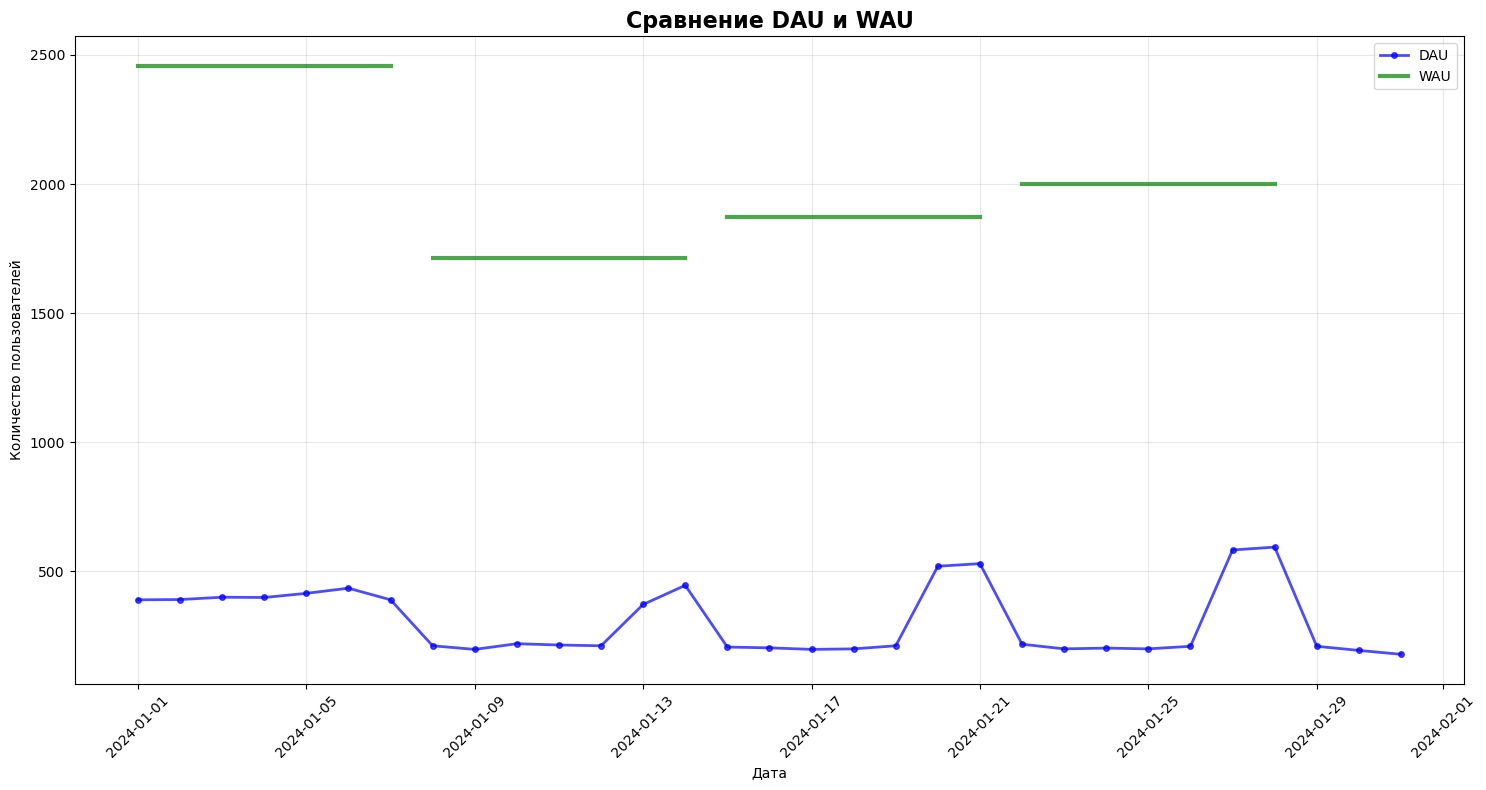

In [21]:
# ВИЗУАЛИЗАЦИЯ DAU И WAU НА ОДНОМ ГРАФИКЕ
print("\n" + "="*50)
print("СОВМЕСТНАЯ ВИЗУАЛИЗАЦИЯ DAU И WAU")
print("="*50)

plt.figure(figsize=(15, 8))

# Визуализация DAU
plt.plot(dau['datetime'], dau['dau'], marker='o', linewidth=2, 
         markersize=4, color='blue', alpha=0.7, label='DAU')

# Визуализация WAU - создаем точки для каждого дня недели
for _, row in wau.iterrows():
    week_dates = df_full_weeks[(df_full_weeks['year'] == row['year']) & 
                              (df_full_weeks['week'] == row['week'])]['date'].unique()
    week_dates.sort()
    
    # Рисуем горизонтальную линию для WAU через все дни недели
    plt.plot(week_dates, [row['wau']] * len(week_dates), 
             linewidth=3, color='green', alpha=0.7, label='WAU' if _ == 0 else "")

plt.title('Сравнение DAU и WAU', fontsize=16, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

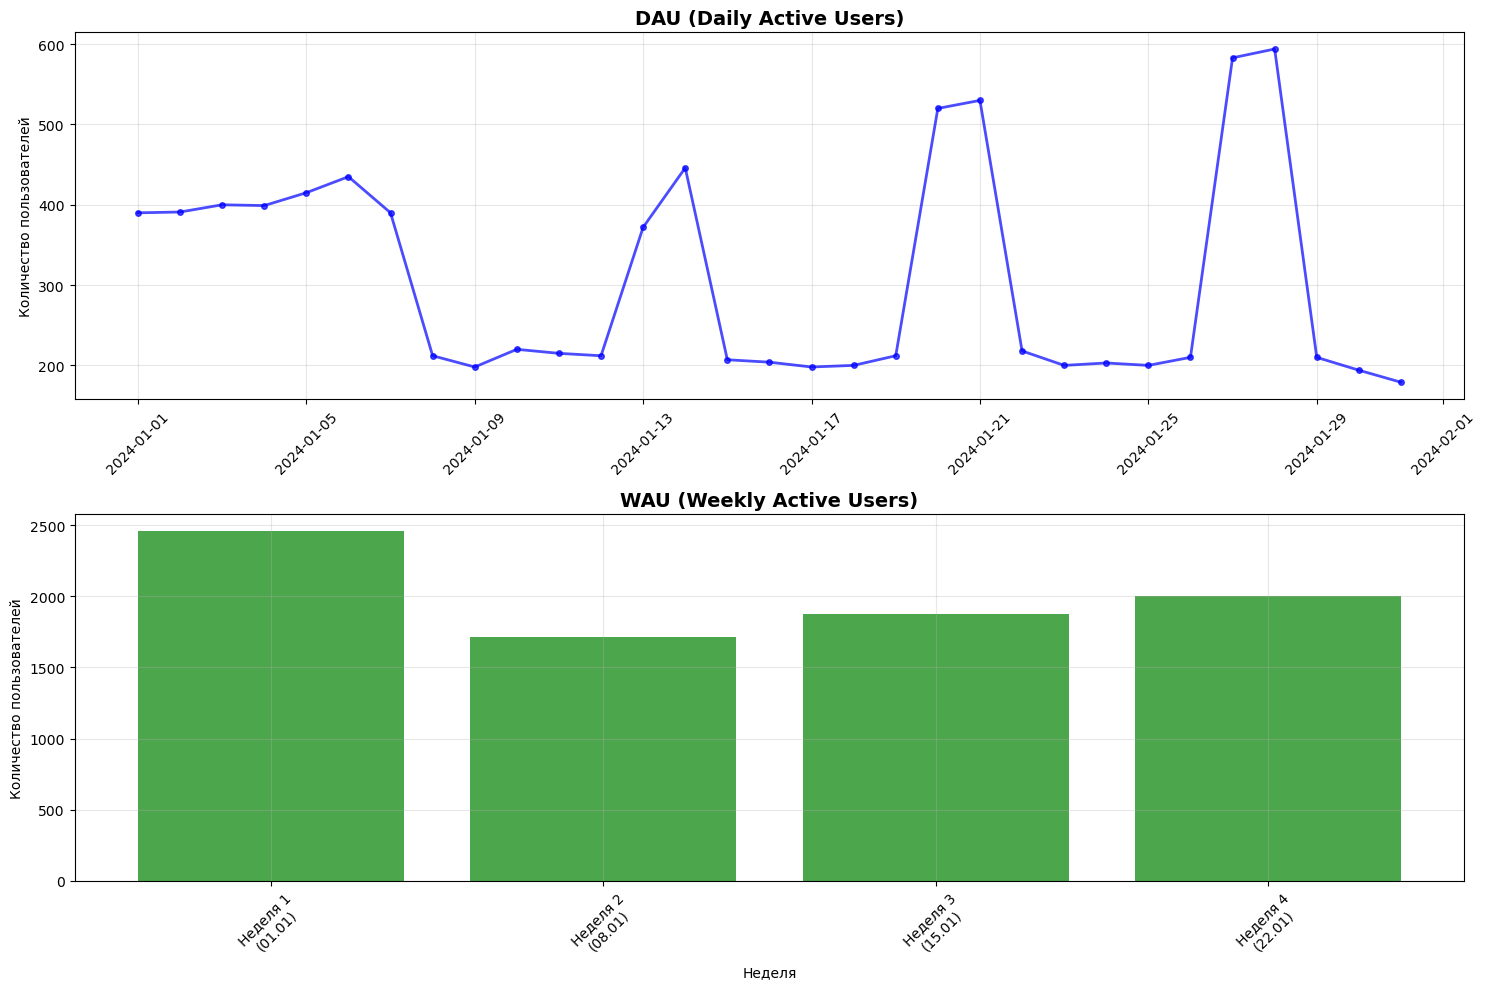

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# График DAU
ax1.plot(dau['datetime'], dau['dau'], marker='o', linewidth=2, markersize=4, color='blue', alpha=0.7)
ax1.set_title('DAU (Daily Active Users)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество пользователей')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# График WAU (столбчатая диаграмма)
wau_bars = ax2.bar(range(len(wau)), wau['wau'], color='green', alpha=0.7)
ax2.set_title('WAU (Weekly Active Users)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Неделя')
ax2.set_ylabel('Количество пользователей')
ax2.set_xticks(range(len(wau)))
ax2.set_xticklabels([f"Неделя {w}\n({pd.to_datetime(d).strftime('%d.%m')})" 
                    for w, d in zip(wau['week'], wau['first_date'])], rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# АНАЛИЗ И ВЫВОДЫ
print("\n" + "="*50)
print("АНАЛИЗ И ВЫВОДЫ")
print("="*50)

print("Ключевые метрики:")
print(f"Средний DAU: {dau['dau'].mean():.1f} пользователей в день")
print(f"Медианный DAU: {dau['dau'].median():.1f} пользователей в день")
print(f"Минимальный DAU: {dau['dau'].min()} пользователей")
print(f"Максимальный DAU: {dau['dau'].max()} пользователей")
print(f"Стандартное отклонение DAU: {dau['dau'].std():.1f}")

print(f"\nСредний WAU: {wau['wau'].mean():.1f} пользователей в неделю")
print(f"Медианный WAU: {wau['wau'].median():.1f} пользователей в неделю")


АНАЛИЗ И ВЫВОДЫ
Ключевые метрики:
Средний DAU: 308.3 пользователей в день
Медианный DAU: 215.0 пользователей в день
Минимальный DAU: 179 пользователей
Максимальный DAU: 594 пользователей
Стандартное отклонение DAU: 133.1

Средний WAU: 2011.5 пользователей в неделю
Медианный WAU: 1938.0 пользователей в неделю


**Изменятся** ли выводы, если поменять определение "активности"? \
Допустим, только действие *play* будет считаться за активность, а не любые действия вообще.

In [24]:
df_play_only = df_final[df_final['event'] == 'play'].copy()
print(f"Записей с событием play: {len(df_play_only)}")
print(f"Уникальных пользователей с play: {df_play_only['id_client'].nunique()}")

# РАСЧЕТ DAU (ТОЛЬКО PLAY)
print("\n" + "="*50)
print("РАСЧЕТ DAU (ТОЛЬКО PLAY)")
print("="*50)

dau_play = df_play_only.groupby('date')['id_client'].nunique().reset_index()
dau_play.columns = ['date', 'dau_play']
dau_play['datetime'] = pd.to_datetime(dau_play['date'])

print("DAU (только play) по дням:")
print(dau_play[['date', 'dau_play']])

# РАСЧЕТ WAU (ТОЛЬКО PLAY)
print("\n" + "="*50)
print("РАСЧЕТ WAU (ТОЛЬКО PLAY)")
print("="*50)

# Добавляем информацию о неделе
df_play_only['year'] = df_play_only['dtime_event'].dt.isocalendar().year
df_play_only['week'] = df_play_only['dtime_event'].dt.isocalendar().week

# Исключаем неполные недели
week_days_count = df_play_only.groupby(['year', 'week'])['date'].nunique()
full_weeks = week_days_count[week_days_count == 7].index

print(f"Полные недели с play: {len(full_weeks)}")

# Фильтруем только полные недели
df_play_full_weeks = df_play_only[df_play_only[['year', 'week']].apply(tuple, axis=1).isin(full_weeks)]

# Рассчитываем WAU
wau_play = df_play_full_weeks.groupby(['year', 'week'])['id_client'].nunique().reset_index()
wau_play.columns = ['year', 'week', 'wau_play']

print("\nWAU (только play) по полным неделям:")
print(wau_play[['year', 'week', 'wau_play']])


Записей с событием play: 2035
Уникальных пользователей с play: 1795

РАСЧЕТ DAU (ТОЛЬКО PLAY)
DAU (только play) по дням:
          date  dau_play
0   2024-01-01        82
1   2024-01-02        81
2   2024-01-03        87
3   2024-01-04        85
4   2024-01-05        81
5   2024-01-06        92
6   2024-01-07        91
7   2024-01-08        51
8   2024-01-09        41
9   2024-01-10        47
10  2024-01-11        41
11  2024-01-12        47
12  2024-01-13        75
13  2024-01-14        89
14  2024-01-15        44
15  2024-01-16        41
16  2024-01-17        45
17  2024-01-18        33
18  2024-01-19        49
19  2024-01-20       107
20  2024-01-21       116
21  2024-01-22        48
22  2024-01-23        39
23  2024-01-24        40
24  2024-01-25        39
25  2024-01-26        40
26  2024-01-27       127
27  2024-01-28       144
28  2024-01-29        43
29  2024-01-30        42
30  2024-01-31        37

РАСЧЕТ WAU (ТОЛЬКО PLAY)
Полные недели с play: 4

WAU (только play) по полным 

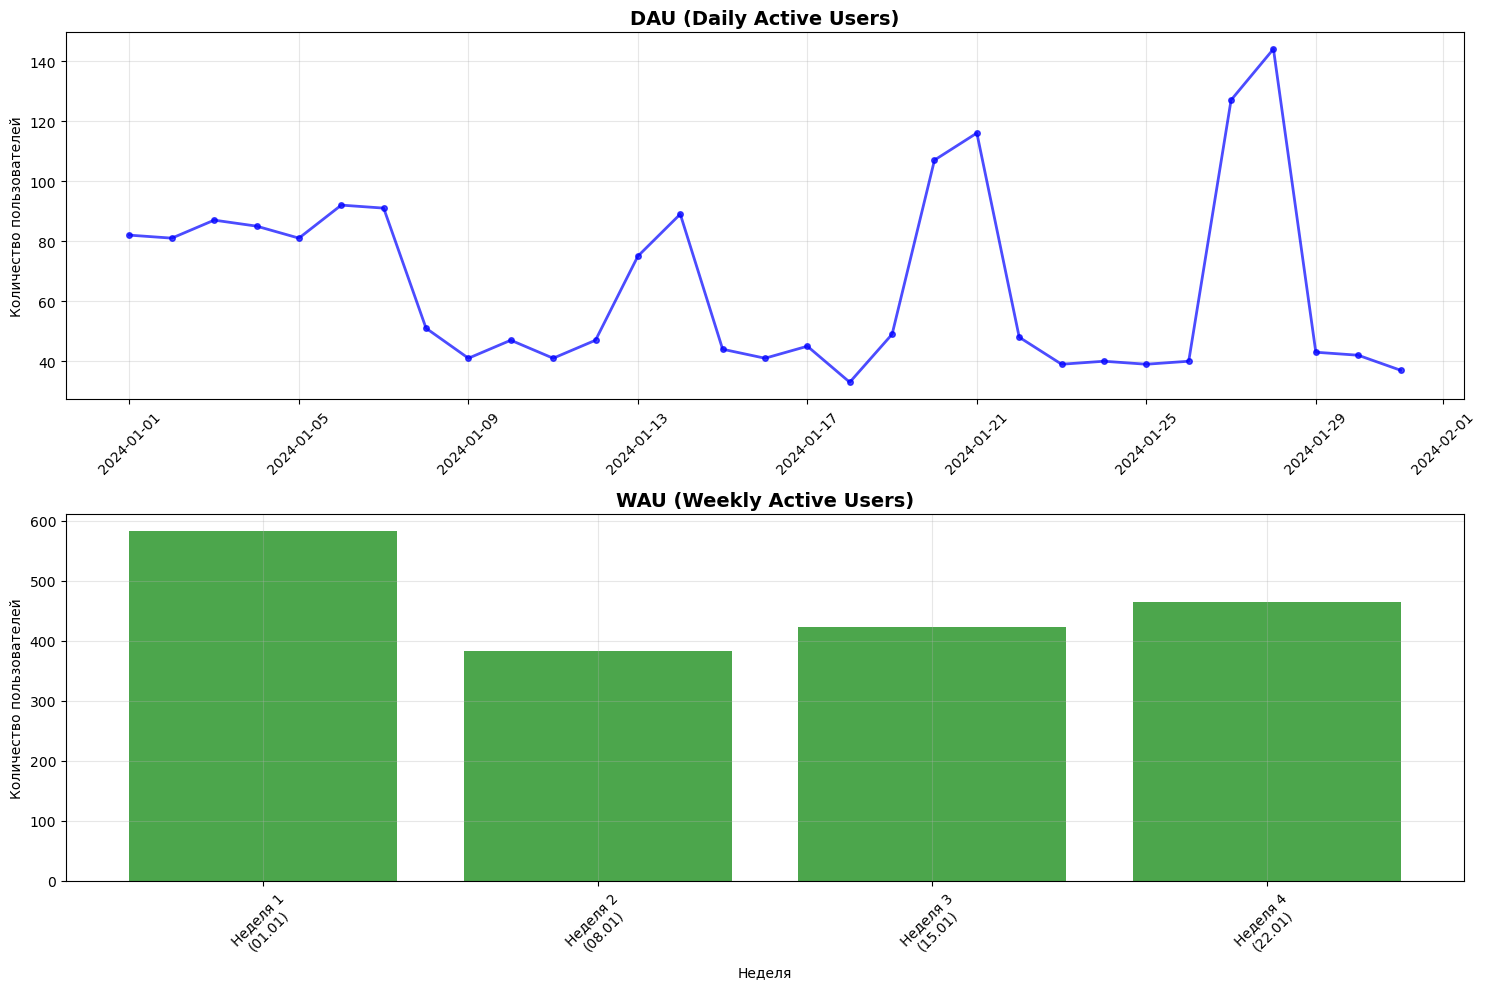

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# График DAU
ax1.plot(dau_play['datetime'], dau_play['dau_play'], marker='o', linewidth=2, markersize=4, color='blue', alpha=0.7)
ax1.set_title('DAU (Daily Active Users)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество пользователей')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# График WAU (столбчатая диаграмма)
wau_bars = ax2.bar(range(len(wau)), wau_play['wau_play'], color='green', alpha=0.7)
ax2.set_title('WAU (Weekly Active Users)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Неделя')
ax2.set_ylabel('Количество пользователей')
ax2.set_xticks(range(len(wau)))
ax2.set_xticklabels([f"Неделя {w}\n({pd.to_datetime(d).strftime('%d.%m')})" 
                    for w, d in zip(wau['week'], wau['first_date'])], rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Несмотря на изменение условий активности** - сама *динамика* показателей WAU/DAU осталась приблизительно той же.

Это, в свою очередь, может навести на то, что действие *play* как раз и задает основную траекторию динамики активности юзеров, отображая реальный уровень вовлеченности клиентов, и что прочие действия, совершаемые нашими клиентами, скорее "вторят" этой динамике.
Это совершенно нормально, даже ожидаемо, тем самым положительно отзывается об состоянии платформы в целом.